<a href="https://colab.research.google.com/github/JohnUfo/python-and-scikit-tutorial/blob/main/business_driven_ml_approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [2]:
train_df = pd.read_csv('/content/drive/MyDrive/rossmann-store-sales/train.csv', low_memory=False)

In [3]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [4]:
store_df = pd.read_csv('/content/drive/MyDrive/rossmann-store-sales/store.csv')

In [5]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [6]:
full_train_df = train_df.merge(store_df, how='left', on='Store')

In [7]:
full_train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [8]:
test_df = pd.read_csv('/content/drive/MyDrive/rossmann-store-sales/test.csv')

In [9]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [10]:
full_test_df = test_df.merge(store_df, how='left', on='Store')

In [11]:
round(full_train_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.43,321.91,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,4.00,2.00,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.82,3849.93,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.15,464.41,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.83,0.38,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.38,0.49,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.18,0.38,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.09,7715.32,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.22,3.21,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.69,5.99,1900.0,2006.0,2010.0,2013.0,2015.0


In [12]:
full_train_df.duplicated().sum()

np.int64(0)

In [13]:
full_train_df['Date'] = pd.to_datetime(full_train_df['Date'])

In [14]:
full_test_df['Date'] = pd.to_datetime(full_test_df['Date'])

In [15]:
full_train_df.Date.min(), full_train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [16]:
full_test_df.Date.min(), full_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

<Axes: xlabel='Sales', ylabel='Count'>

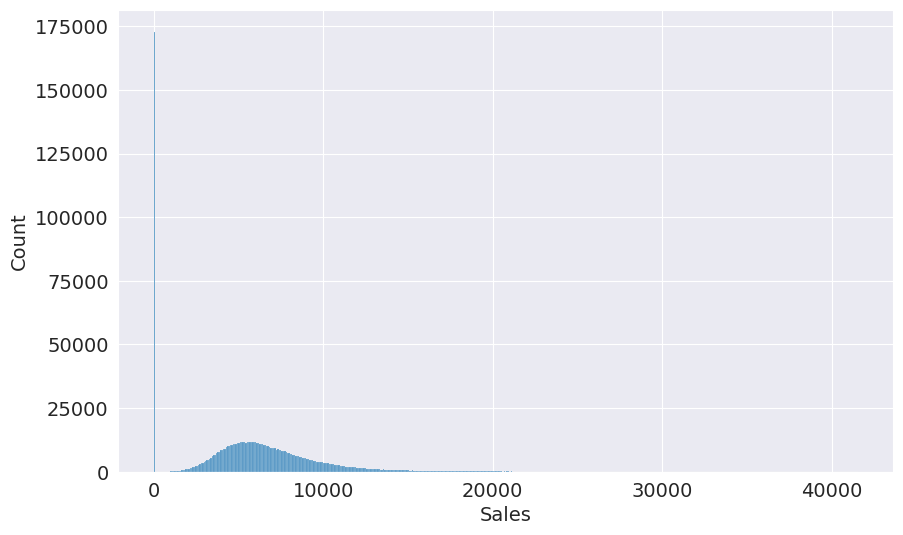

In [17]:
sns.histplot(data=full_train_df, x='Sales')

In [18]:
full_train_df.Open.value_counts()

,count
Open,
1,844392
0,172817


In [19]:
full_train_df.Sales.value_counts()[0]

np.int64(172871)

In [20]:
full_train_df = full_train_df[full_train_df.Open==1].copy()

<Axes: xlabel='Sales', ylabel='Count'>

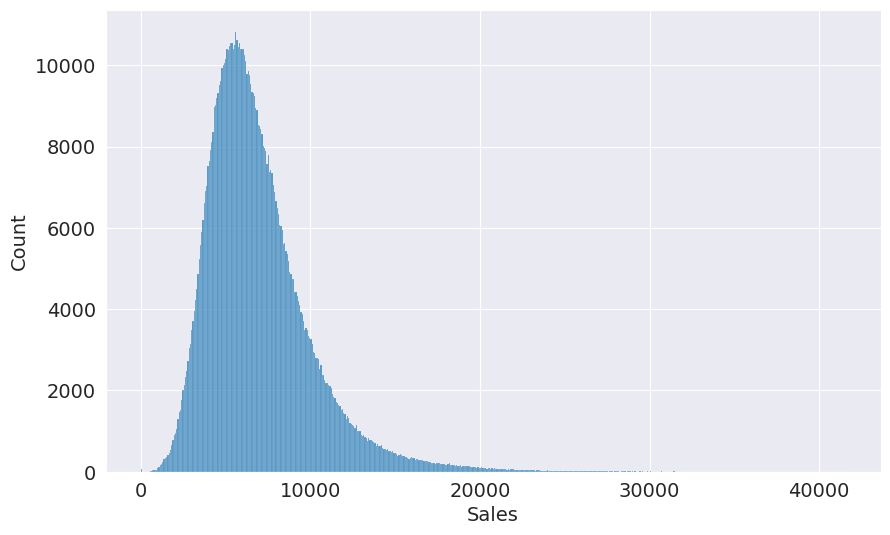

In [21]:
sns.histplot(data=full_train_df, x='Sales')

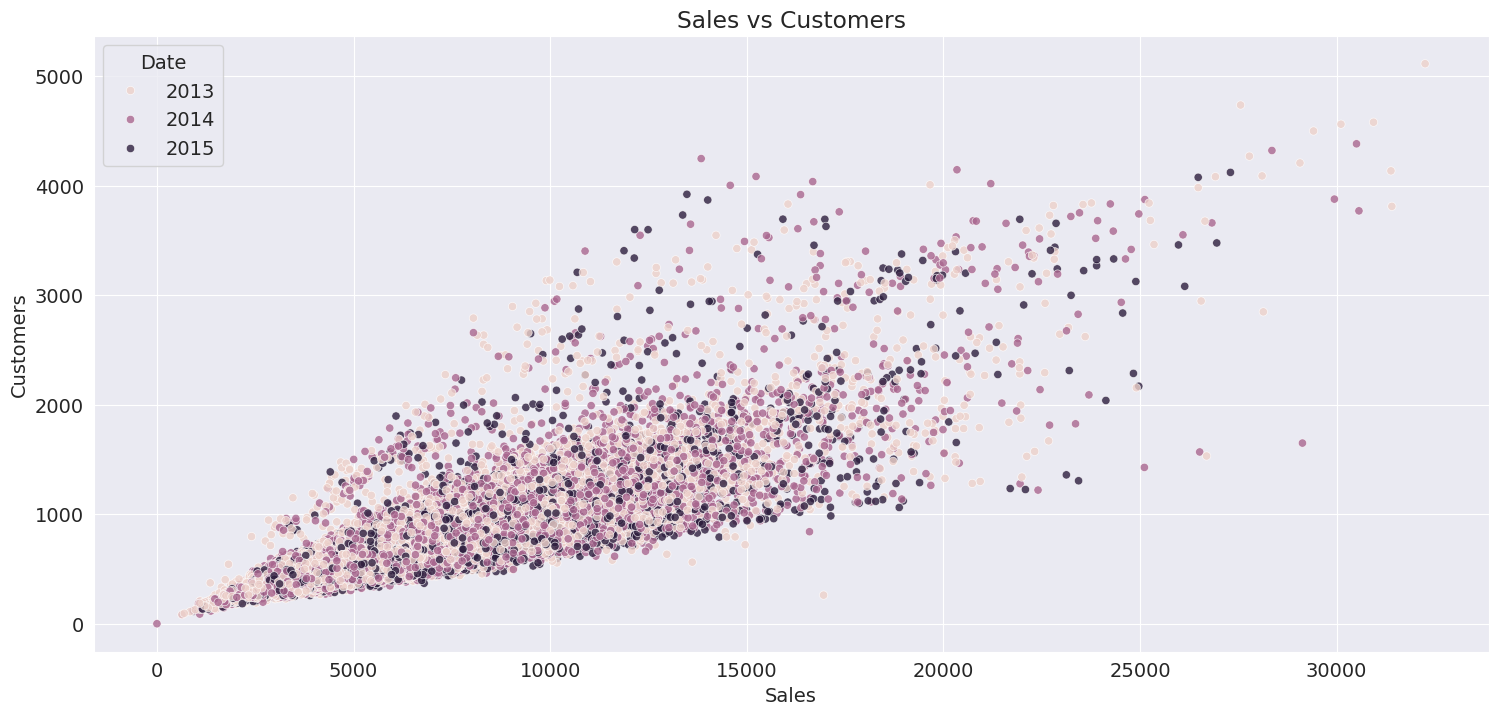

In [22]:
plt.figure(figsize=(18, 8))
temp_train_df = full_train_df.sample(40000)
sns.scatterplot(x=temp_train_df.Sales, y=temp_train_df.Customers, hue=temp_train_df.Date.dt.year, alpha=0.8)
plt.title('Sales vs Customers')
plt.show()

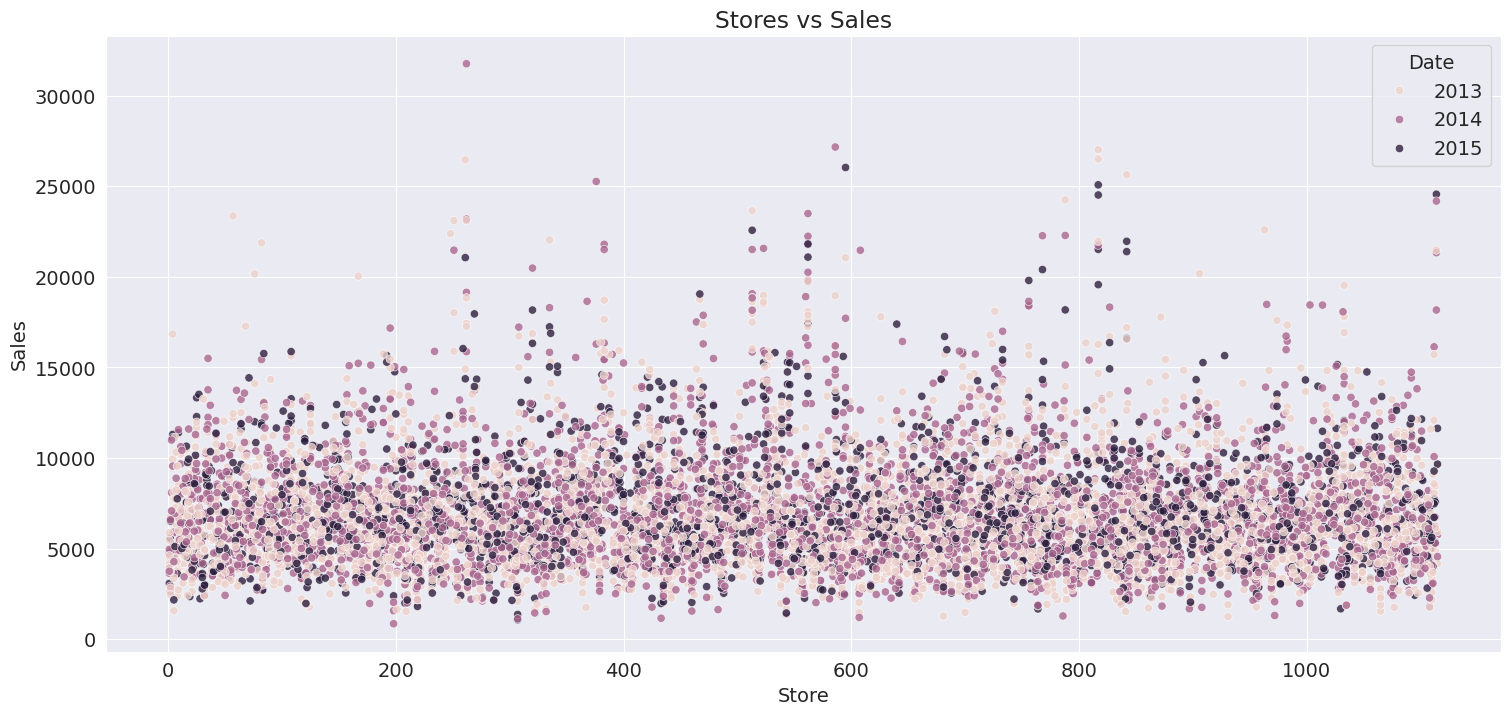

In [23]:
plt.figure(figsize=(18, 8))
temp_train_df = full_train_df.sample(10000)
sns.scatterplot(x=temp_train_df.Store, y=temp_train_df.Sales, hue=temp_train_df.Date.dt.year, alpha=0.8)
plt.title('Stores vs Sales')
plt.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

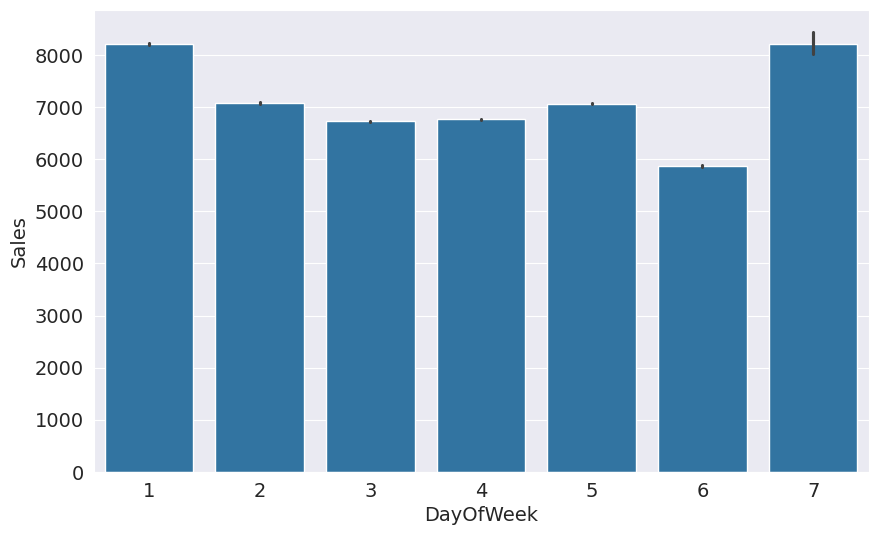

In [24]:
sns.barplot(data=full_train_df, x='DayOfWeek', y='Sales')

<Axes: xlabel='Promo', ylabel='Sales'>

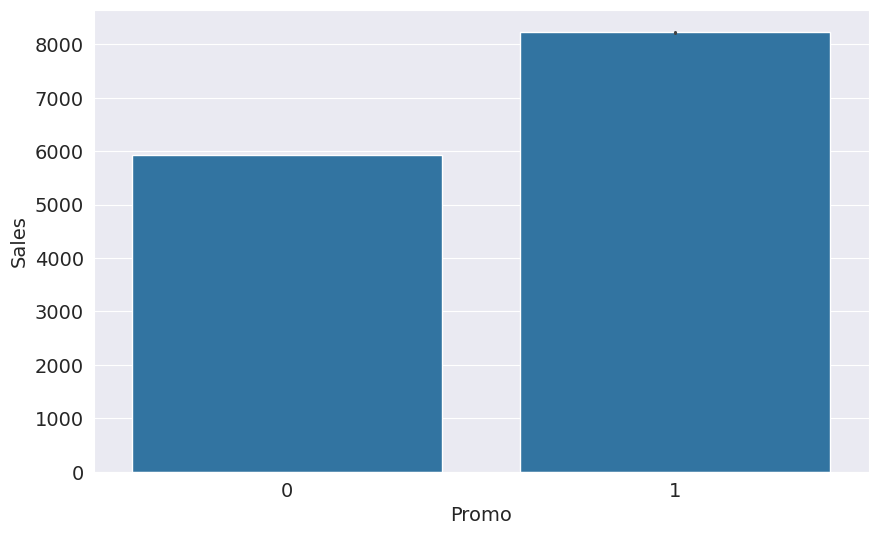

In [25]:
sns.barplot(data=full_train_df, x='Promo', y='Sales')

In [26]:
numeric_full_train_df = full_train_df.select_dtypes(include=np.number)

In [27]:
numeric_full_train_df.corr()['Sales'].sort_values(ascending=False)

,Sales
Sales,1.000000
Customers,0.823597
Promo,0.368145
Promo2SinceWeek,0.095311
SchoolHoliday,0.038617
CompetitionOpenSinceYear,0.016101
Store,0.007710
Promo2SinceYear,-0.034713
CompetitionDistance,-0.036396
CompetitionOpenSinceMonth,-0.043489


In [28]:
full_train_df['Day'] = full_train_df.Date.dt.day
full_train_df['Month'] = full_train_df.Date.dt.month
full_train_df['Year'] = full_train_df.Date.dt.year

In [29]:
full_test_df['Day'] = full_test_df.Date.dt.day
full_test_df['Month'] = full_test_df.Date.dt.month
full_test_df['Year'] = full_test_df.Date.dt.year

<Axes: xlabel='Year', ylabel='Sales'>

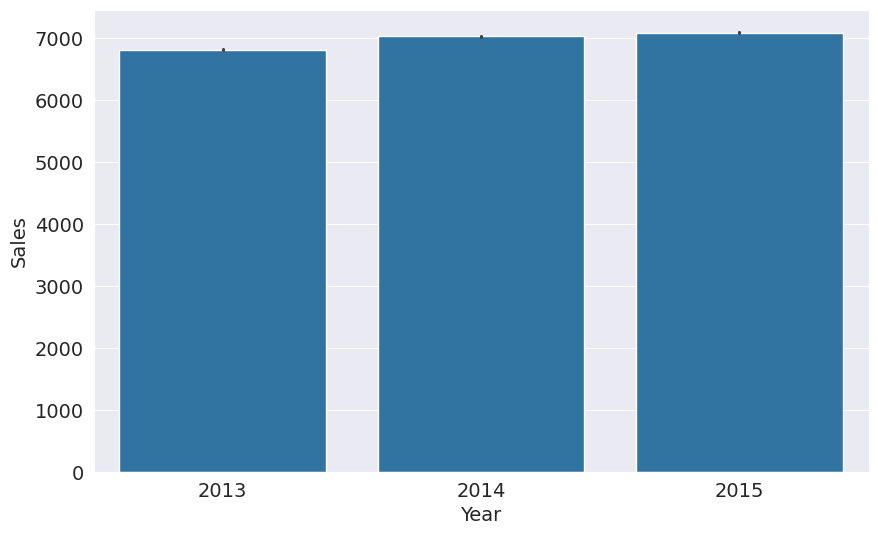

In [30]:
sns.barplot(data=full_train_df, x='Year', y='Sales')

<Axes: xlabel='Month', ylabel='Sales'>

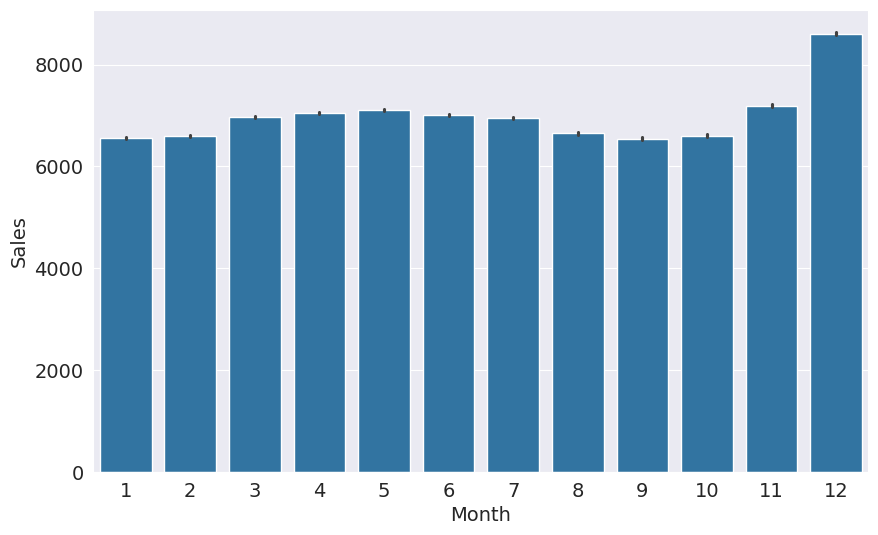

In [31]:
sns.barplot(data=full_train_df, x='Month', y='Sales')

# Train/Validation/Test Split

In [32]:
train_size = int(0.75 * len(full_train_df))
train_size

633294

In [33]:
sorted_df = full_train_df.sort_values('Date')
train_df, val_df = sorted_df[:train_size], sorted_df[train_size:]

In [34]:
len(train_df), len(val_df)

(633294, 211098)

In [35]:
train_df.Date.min(), train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2014-12-10 00:00:00'))

In [36]:
val_df.Date.min(), val_df.Date.max()

(Timestamp('2014-12-10 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [37]:
test_df.Date.min(), test_df.Date.max()

('2015-08-01', '2015-09-17')

# Input and Target columns

In [38]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Day', 'Month', 'Year'],
      dtype='object')

In [39]:
input_cols = ['Store','DayOfWeek','Promo','StateHoliday', 'StoreType','Assortment','Day','Month','Year']
target_col = 'Sales'

In [40]:
full_train_df[input_cols].nunique()

,0
Store,1115
DayOfWeek,7
Promo,2
StateHoliday,4
StoreType,4
Assortment,3
Day,31
Month,12
Year,3


In [41]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [42]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [43]:
test_inputs = full_test_df[input_cols].copy()

In [44]:
numeric_cols = ['Store','Day','Month','Year']
categorical_cols = ['DayOfWeek','Promo','StateHoliday', 'StoreType','Assortment']

# Imputation, Scaling and Encode

In [45]:
from sklearn.impute import SimpleImputer

In [46]:
imputer = SimpleImputer(strategy='mean').fit(train_inputs[numeric_cols])

In [47]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [48]:
from sklearn.preprocessing import MinMaxScaler

In [49]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [50]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [51]:
from sklearn.preprocessing import OneHotEncoder

In [52]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [53]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [54]:
train_inputs

,Store,DayOfWeek,Promo,StateHoliday,StoreType,Assortment,Day,Month,Year,DayOfWeek_1,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
1017190,0.983842,2,0,a,b,b,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016179,0.075404,2,0,a,b,a,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016353,0.231598,2,0,a,b,b,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016356,0.234291,2,0,a,b,a,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016368,0.245063,2,0,a,b,b,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256632,0.667864,3,0,0,a,a,0.3,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
256642,0.677738,3,0,0,a,c,0.3,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
256634,0.669659,3,0,0,c,c,0.3,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
256633,0.668761,3,0,0,d,c,0.3,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [55]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [56]:
X_train

,Store,Day,Month,Year,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
1017190,0.983842,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016179,0.075404,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016353,0.231598,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016356,0.234291,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016368,0.245063,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256632,0.667864,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
256642,0.677738,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
256634,0.669659,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
256633,0.668761,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [57]:
def return_mean(inputs):
  return np.full(len(inputs), full_train_df.Sales.mean())

In [58]:
train_preds = return_mean(X_train)

In [59]:
train_preds

array([6955.51429076, 6955.51429076, 6955.51429076, ..., 6955.51429076,
       6955.51429076, 6955.51429076])

In [60]:
from sklearn.metrics import mean_squared_error

In [61]:
np.sqrt(mean_squared_error(train_preds, train_targets))

np.float64(3082.450443277419)

In [62]:
np.sqrt(mean_squared_error(return_mean(X_val), val_targets))

np.float64(3168.6033635047716)

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
linreg = LinearRegression().fit(X_train, train_targets)

In [65]:
train_preds = linreg.predict(X_train)

In [66]:
np.sqrt(mean_squared_error(train_preds, train_targets))

np.float64(2741.587191916578)

In [67]:
val_preds = linreg.predict(X_val)
val_preds

array([5619.13905784, 5619.23296627, 5997.82860958, ..., 8646.58181098,
       8401.32998235, 7843.07278986])

In [68]:
np.sqrt(mean_squared_error(val_preds, val_targets))

np.float64(2817.7797940117125)

In [69]:
def try_model(model):
  model.fit(X_train, train_targets)
  train_preds = model.predict(X_train)
  val_preds = model.predict(X_val)

  train_rmse = np.sqrt(mean_squared_error(train_preds, train_targets))
  val_rmse = np.sqrt(mean_squared_error(val_preds, val_targets))
  return train_rmse, val_rmse

In [70]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [71]:
try_model(LinearRegression())

(np.float64(2741.587191916578), np.float64(2817.7797940117125))

In [72]:
try_model(Ridge())

(np.float64(2741.5871950814444), np.float64(2817.7784665409868))

In [73]:
try_model(Lasso())

(np.float64(2741.7143904640566), np.float64(2817.9472924045217))

In [74]:
try_model(ElasticNet())

(np.float64(2879.0432103903954), np.float64(2972.6658860503385))

In [75]:
try_model(SGDRegressor())

(np.float64(2742.341426080449), np.float64(2824.5043564657362))

In [76]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [77]:
tree = DecisionTreeRegressor(random_state=42)
try_model(tree)

(np.float64(0.0), np.float64(1559.7378600480247))

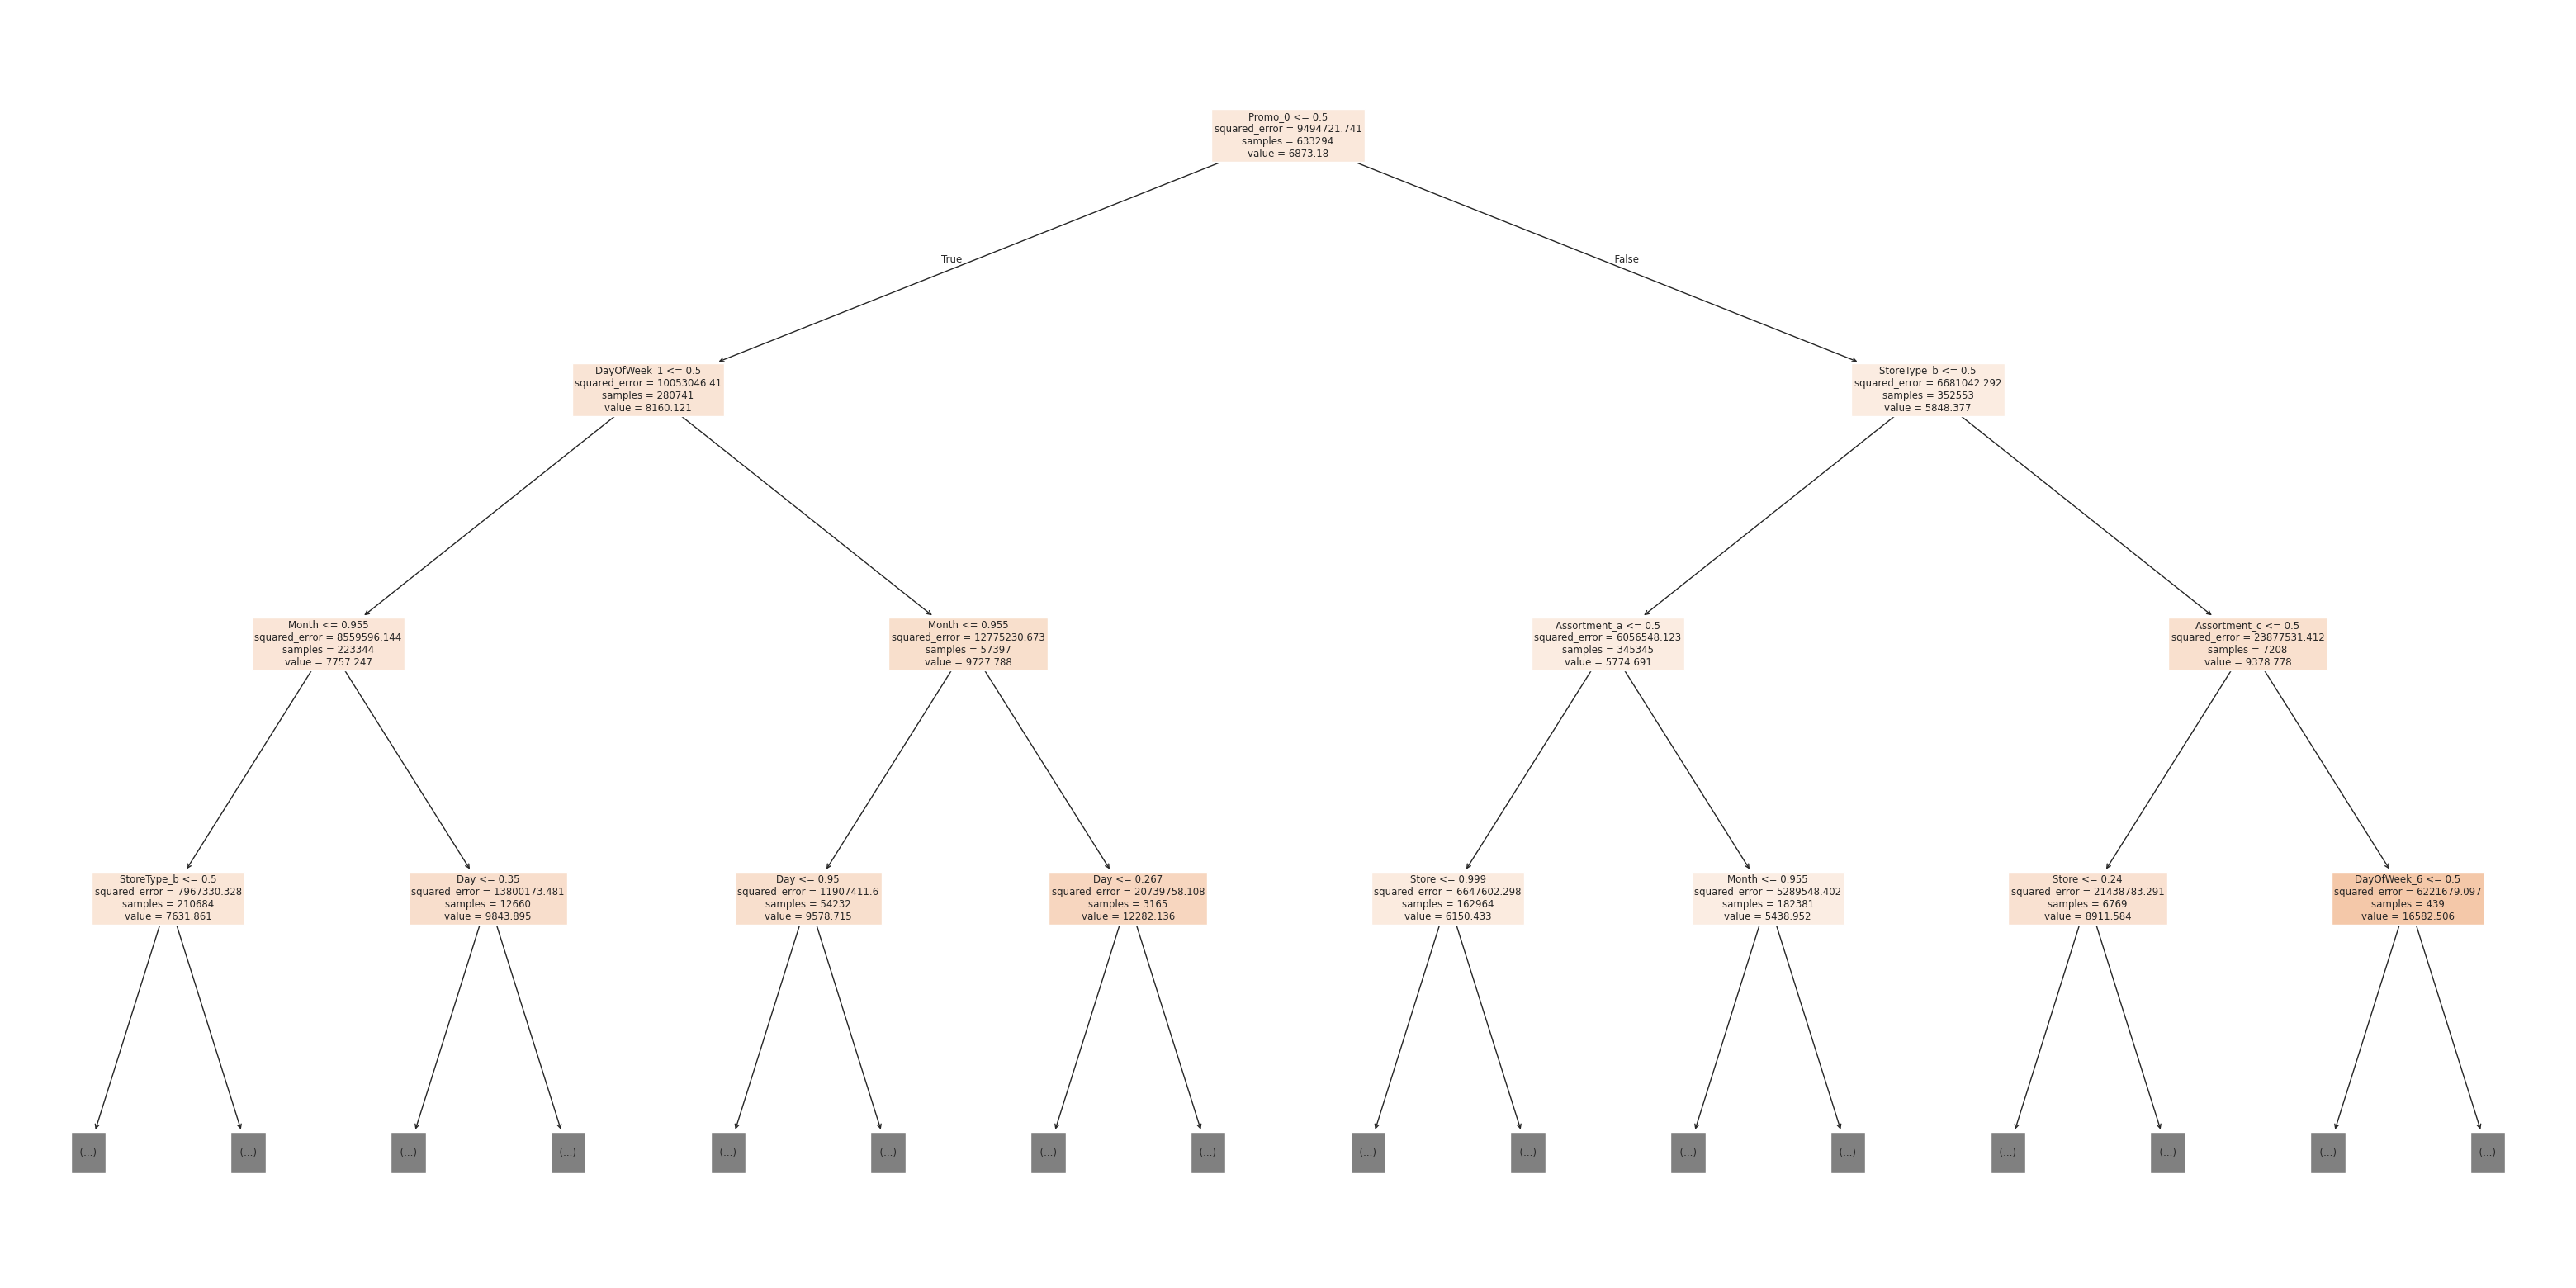

In [78]:
plt.figure(figsize=(40, 20))
plot_tree(tree,max_depth=3, filled=True, feature_names=numeric_cols+encoded_cols);
plt.show()

In [79]:
from sklearn.ensemble import RandomForestRegressor

In [80]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=10)
try_model(rf)

(np.float64(561.3371197812796), np.float64(1422.3914589238575))

In [81]:
importance_df = pd.DataFrame({
    'features': numeric_cols + encoded_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,features,importance
0,Store,0.607425
11,Promo_0,0.083405
12,Promo_1,0.055607
1,Day,0.049124
2,Month,0.047217
4,DayOfWeek_1,0.033610
18,StoreType_b,0.022814
20,StoreType_d,0.013649
17,StoreType_a,0.013027
23,Assortment_c,0.013022


<Axes: xlabel='importance', ylabel='features'>

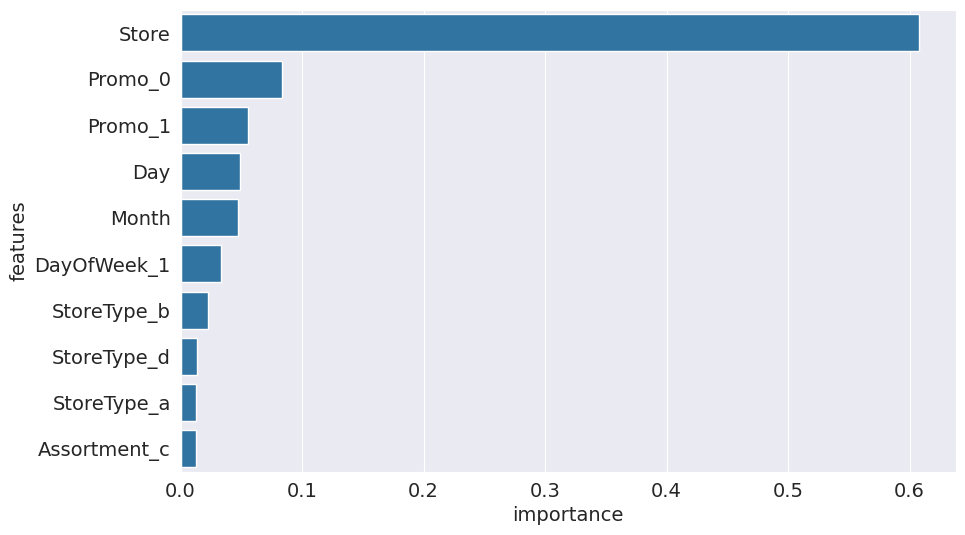

In [82]:
sns.barplot(data=importance_df.head(10), x='importance', y='features')

In [83]:
def predict_input (model, single_input):
  if single_input['Open'] == 0:
    return 0.

  input_df = pd. DataFrame([single_input])
  input_df[ 'Date'] = pd.to_datetime (input_df.Date)
  input_df['Day'] = input_df.Date.dt.day
  input_df[ 'Month'] = input_df.Date.dt.month
  input_df[ 'Year'] = input_df.Date.dt.year
  input_df[numeric_cols] = imputer.transform (input_df [numeric_cols])
  input_df[numeric_cols] = scaler.transform(input_df[ numeric_cols])
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
  X_input = input_df[numeric_cols + encoded_cols]
  pred = model.predict(X_input)[0]
  return pred

In [84]:
sample_input = {
    'Id': 1,
    'Store': 1,
    'DayOfWeek': 4,
    'Date': '2015-09-17 00:00:00',
    'Open': 1.0,
    'Promo': 1,
    'StateHoliday': '0',
    'SchoolHoliday': 0,
    'StoreType': 'c',
    'Assortment': 'a',
    'CompetitionDistance': 1270.0,
    'CompetitionOpenSinceMonth': 9.0,
    'CompetitionOpenSinceYear': 2008.0,
    'Promo2': 0,
    'Promo2SinceWeek': np.nan,
    'Promo2SinceYear': np.nan,
    'PromoInterval': np.nan
}

sample_input

{'Id': 1,
 'Store': 1,
 'DayOfWeek': 4,
 'Date': '2015-09-17 00:00:00',
 'Open': 1.0,
 'Promo': 1,
 'StateHoliday': '0',
 'SchoolHoliday': 0,
 'StoreType': 'c',
 'Assortment': 'a',
 'CompetitionDistance': 1270.0,
 'CompetitionOpenSinceMonth': 9.0,
 'CompetitionOpenSinceYear': 2008.0,
 'Promo2': 0,
 'Promo2SinceWeek': nan,
 'Promo2SinceYear': nan,
 'PromoInterval': nan}

In [86]:
predict_input(rf,sample_input)

np.float64(4170.5)

In [99]:
test_preds = rf.predict(X_test)
test_preds

array([ 4170.5,  7746.2,  8919.7, ...,  6100.6, 20353.4,  6688.5])

In [100]:
submission_df = pd.read_csv('/content/drive/MyDrive/rossmann-store-sales/sample_submission.csv')
submission_df

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
41083,41084,0
41084,41085,0
41085,41086,0
41086,41087,0


In [102]:
submission_df['Sales'] = test_preds

In [104]:
submission_df.fillna(0, inplace=True)

In [105]:
submission_df

,Id,Sales
0,1,4170.5
1,2,7746.2
2,3,8919.7
3,4,6957.5
4,5,6362.5
...,...,...
41083,41084,3129.8
41084,41085,8361.8
41085,41086,6100.6
41086,41087,20353.4


In [109]:
test_df['Open'].fillna(1).astype('int') * test_preds

,Open
0,4170.5
1,7746.2
2,8919.7
3,6957.5
4,6362.5
...,...
41083,3129.8
41084,8361.8
41085,6100.6
41086,20353.4


In [110]:
submission_df.to_csv('submission.csv', index=None)